# Residential pricing optimization using ML (Machine learning)

## Objetive

The main goal of this project is to develop machine learning models to **predict and optimize housing prices** based on various factors, such as leads, visits, and reservations. By leveraging models like **XGBoost**, **RandomForest**, and **time series forecasting**, this project aims to support data-driven pricing decisions, prevent unprofitable pricing strategies, and ensure optimal price points for residential properties.


## Business Understanding

## Problem

In the real estate industry, pricing decisions often rely on intuition or simple rule-based approaches, which can lead to suboptimal pricing and reduced profitability. This project addresses the following key challenges:

1. **Accurate Price Prediction**: Determining the most accurate price for a property based on relevant business metrics.
2. **Price Optimization**: Preventing prices from falling outside the optimal range that maximizes profitability.
3. **Data-Driven Decisions**: Shifting from intuition-based pricing to data-driven insights for better decision-making.

The core problem is to create a reliable model that can estimate the ideal price for a property based on the observed data and business metrics. Additionally, the model should help in identifying pricing anomalies that could affect profitability.

## Methodology

This project follows the **CRISP-DM** framework to ensure a structured approach to data mining:

1. **Business Understanding**: Understanding the key business variables (leads, visits, reservations) and the target variable (price).
2. **Data Understanding**: Exploring and preprocessing the data to ensure its quality and suitability for modeling.
3. **Data Preparation**: Cleaning, transforming, and preparing the data, including feature engineering and encoding categorical variables.
4. **Modeling**: Training multiple machine learning models (Random Forest, XGBoost, and possibly time-series forecasting models) to predict housing prices.
5. **Evaluation**: Evaluating the performance of each model using metrics such as **RMSE**, **MAE**, and **R²**.
6. **Deployment**: If applicable, preparing the model for deployment (though this step will not be included in the current scope).

## Results Expected

The expected outcome of this project is the creation of a robust machine learning model that can:

- **Accurately predict housing prices** based on key features like leads, visits, and reservations.
- **Provide insights** on which features are most important for determining prices, enabling better decision-making.
- **Optimize pricing** to ensure that it aligns with market conditions and business goals, avoiding prices that are too high or too low.

Ultimately, the goal is to create a tool that helps real estate professionals set prices based on data, improving profitability and reducing pricing errors.

## Models Used

- **Random Forest**: A versatile ensemble learning method that will provide a good baseline for understanding feature importance and predicting prices.
- **XGBoost**: A more advanced boosting model known for its performance in regression tasks, which will be used to fine-tune predictions.
- **Time Series Forecasting** (if applicable): A forecasting approach to predict future prices based on past data.

---

In [24]:
pip install xgboost

   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 1.3/150.0 MB 11.3 MB/s eta 0:00:14
   - -------------------------------------- 6.3/150.0 MB 19.3 MB/s eta 0:00:08
   -- ------------------------------------- 11.0/150.0 MB 20.9 MB/s eta 0:00:07
   ---- ----------------------------------- 18.6/150.0 MB 25.0 MB/s eta 0:00:06
   ----- ---------------------------------- 21.5/150.0 MB 22.3 MB/s eta 0:00:06
   ------ --------------------------------- 23.1/150.0 MB 20.6 MB/s eta 0:00:07
   ------- -------------------------------- 28.3/150.0 MB 20.6 MB/s eta 0:00:06
   -------- ------------------------------- 33.6/150.0 MB 21.3 MB/s eta 0:00:06
   --------- ------------------------------ 37.5/150.0 MB 20.9 MB/s eta 0:00:06
   ----------- ---------------------------- 43.8/150.0 MB 21.9 MB/s eta 0:00:05
   ------------ --------------------------- 48.0/150.0 MB 21.7 MB/s eta 0:00:05
   ------------- -------------------------- 52.4/15

In [209]:
# Import the required libraries
# Standard Libraries
import pandas as pd
import numpy as np
import joblib

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Model libraries
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.inspection import PartialDependenceDisplay

# Accuracy and evaluation
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Plotting
import seaborn as sns
import matplotlib.pyplot as plt

# Enviroment
import os
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [5]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100

---

## Data understanding

### Data overview

In [114]:
# Get the dataframe from /data
data = pd.read_csv('data/Weekly.csv')

In [116]:
data.head()

,ID,Fecha,Semana,Proyecto,Modelo,Website Leads,Showroom Visits,Modelo Tipo,Separaciones,Price,Inventario restante,Ventas,Conversión Separaciones (%),Conversión Ventas (%),Inventario Disponible,Precio Promedio del Proyecto-Modelo
0,01/01/2024CBR-BR2,01/01/2024,1,CBR,BR2,0,0,Normal,0,0,0,NO,0.000000,NaN,NaN,NaN
1,01/01/2024CBR-COR3,01/01/2024,1,CBR,COR3,28,1,Normal,0,0,0,NO,0.000000,NaN,NaN,NaN
2,01/01/2024CBR-VIS2,01/01/2024,1,CBR,VIS2,50,7,Normal,3,"2,550,000.00",0,SI,0.428571,NaN,NaN,NaN
3,01/01/2024ALS-IB-3N,01/01/2024,1,ALS,IB-3N,20,0,Normal,0,0,0,NO,0.000000,NaN,NaN,NaN
4,01/01/2024ALS-IB-6,01/01/2024,1,ALS,IB-6,34,6,Normal,1,"2,760,000.00",0,SI,NaN,NaN,NaN,NaN


In [118]:
data.columns

Index(['ID', 'Fecha', 'Semana', 'Proyecto', 'Modelo', 'Website Leads',
       'Showroom Visits', 'Modelo Tipo', 'Separaciones', 'Price',
       'Inventario restante', 'Ventas', 'Conversión Separaciones (%)',
       'Conversión Ventas (%)', 'Inventario Disponible',
       'Precio Promedio del Proyecto-Modelo'],
      dtype='object')

In [120]:
data.dtypes

ID                                      object
Fecha                                   object
Semana                                   int64
Proyecto                                object
Modelo                                  object
Website Leads                            int64
Showroom Visits                          int64
Modelo Tipo                             object
Separaciones                             int64
Price                                   object
Inventario restante                      int64
Ventas                                  object
Conversión Separaciones (%)            float64
Conversión Ventas (%)                  float64
Inventario Disponible                  float64
Precio Promedio del Proyecto-Modelo    float64
dtype: object

- 1197 Rows
- Columns:
  - ID: Unique ID from system ERP
  - Fecha: First day of the week
  - Semana: Week from year
  - Proyecto: Name of proyect inside the enterprise
  - Modelo: Type of residential/housing that contains the data
  - Website lead: Are the potentials customers or visitors
  - Showroom visits: Number of visit to check the residential/housing presential
  - Separaciones: ** Number of books after of showroom stage
  - Price: **It´s the target** and is the actual price of housing (The number 0 is the values that not are ready)
  - Inventario restante: Its the stock of residentials or number of available residentials/housings
  - Conversión Separaciones (%): It´s the number of percent when the customers passed from 'Showroom stage' -> 'Separaciones'
  - Conversión Ventas (%): It´s the number of percent when the customers passed from 'Separaciones' -> 'Ventas'
  - Inventario Disponible: Number of residentials in stock
  - Precio Promedio del Proyecto-Modelo: Its the average of price by model

---

## Data preparation

In [124]:
# Columns Delete
del data['ID'] # Not i
del data['Semana'] # Use the Fecha
del data['Conversión Ventas (%)']
del data['Precio Promedio del Proyecto-Modelo']
del data['Inventario Disponible']

In [126]:
# Convert data
data['Fecha'] = pd.to_datetime(data['Fecha'], errors='coerce')
data['Price'] = data['Price'].replace('[\$,]', '', regex=True).astype(float)
data['Ventas'] = data['Ventas'].replace(['NO', 'SI'], [0, 1])

In [128]:
# Delete NA Fecha for now, because have a lot null
data = data.dropna(subset=['Fecha'])
data['Fecha'] = pd.to_datetime(data['Fecha'], errors='coerce')

In [130]:
data['Conversión Separaciones (%)'] = data['Separaciones'] / data['Showroom Visits']
data['Conversión Separaciones (%)'] = data['Conversión Separaciones (%)'].replace([np.inf, -np.inf], 0).fillna(0)

In [132]:
# Check the data not contains null
print(data.isnull().sum())

Fecha                          0
Proyecto                       0
Modelo                         0
Website Leads                  0
Showroom Visits                0
Modelo Tipo                    0
Separaciones                   0
Price                          0
Inventario restante            0
Ventas                         0
Conversión Separaciones (%)    0
dtype: int64


In [134]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 483 entries, 0 to 1133
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Fecha                        483 non-null    datetime64[ns]
 1   Proyecto                     483 non-null    object        
 2   Modelo                       483 non-null    object        
 3   Website Leads                483 non-null    int64         
 4   Showroom Visits              483 non-null    int64         
 5   Modelo Tipo                  483 non-null    object        
 6   Separaciones                 483 non-null    int64         
 7   Price                        483 non-null    float64       
 8   Inventario restante          483 non-null    int64         
 9   Ventas                       483 non-null    int64         
 10  Conversión Separaciones (%)  483 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(5), objec

In [136]:
# Create Dummies
data = pd.get_dummies(data)

In [138]:
# Create values for Month and Year
data['Mes'] = data['Fecha'].dt.month
data['Año'] = data['Fecha'].dt.year

In [140]:
# Delete Fecha because dont use with Random
del data['Fecha'] # Not use

In [142]:
data.head()

,Website Leads,Showroom Visits,Separaciones,Price,Inventario restante,Ventas,Conversión Separaciones (%),Proyecto_ALS,Proyecto_CBR,Proyecto_LFA,Proyecto_MTA,Proyecto_NOV,Proyecto_RAL,Proyecto_SPA,Proyecto_STA,Modelo_AL8,Modelo_AMA,Modelo_AMD,Modelo_ATT2,Modelo_BR2,Modelo_COR3,Modelo_CU-8,Modelo_IB-3N,Modelo_IB-6,Modelo_K3-7,Modelo_K7,Modelo_L-TS3,Modelo_L-VAL,Modelo_LI3,Modelo_MS-7,Modelo_MS8,Modelo_PRO2,Modelo_VIS2,Modelo Tipo_Normal,Mes,Año
0,0,0,0,0.0,0,0,0.000000,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,1,2024
1,28,1,0,0.0,0,0,0.000000,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,1,2024
2,50,7,3,2550000.0,0,1,0.428571,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,1,2024
3,20,0,0,0.0,0,0,0.000000,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,1,2024
4,34,6,1,2760000.0,0,1,0.166667,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,1,2024


### Exploratory Data Analisys **EDA** 

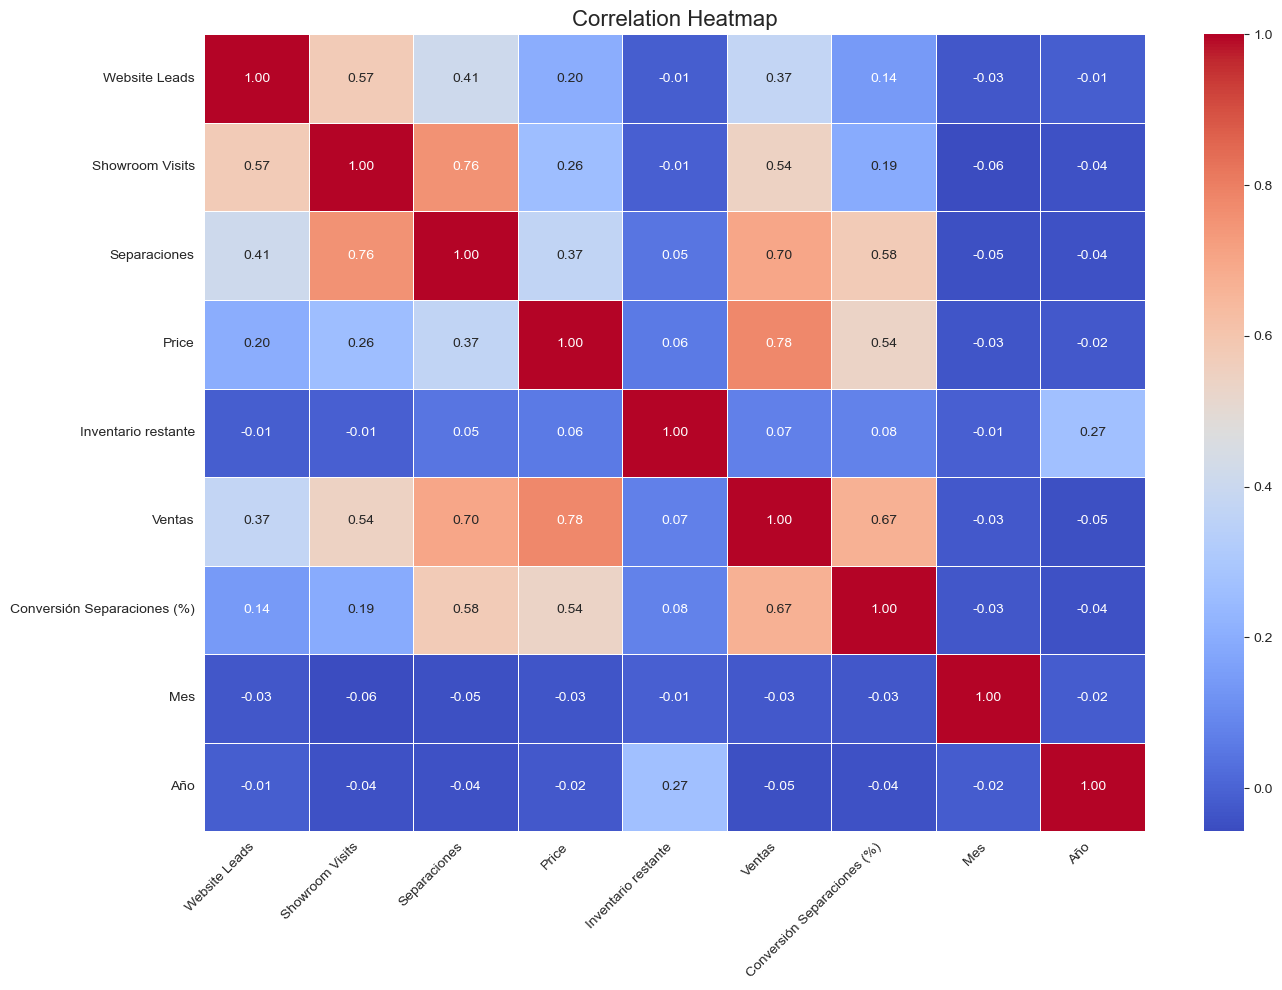

In [144]:
correlation = data.select_dtypes(include=['number']).corr()
plt.figure(figsize=(14, 10))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

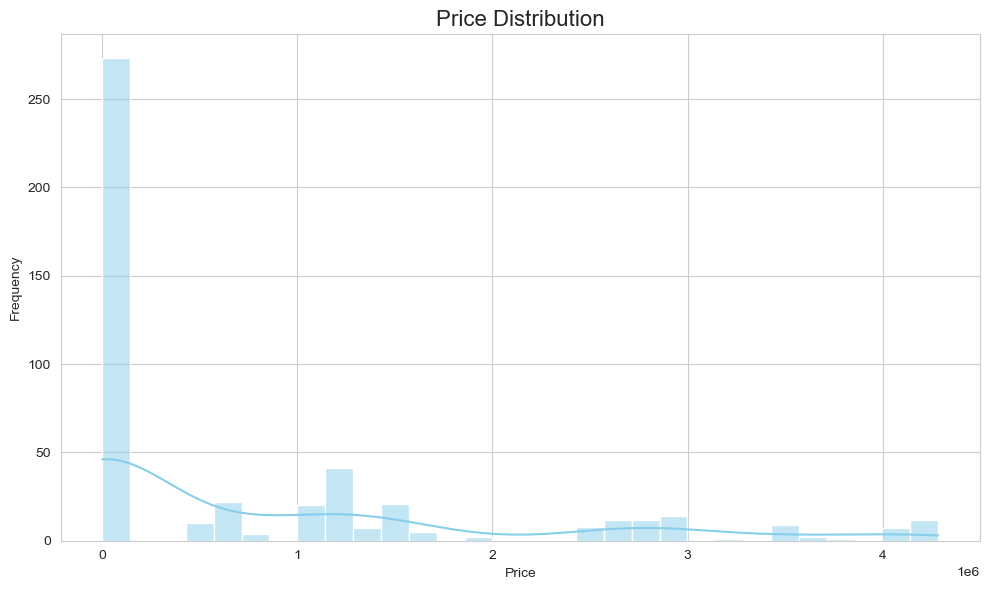

In [146]:
plt.figure(figsize=(10, 6))
sns.histplot(data['Price'], bins=30, kde=True, color="skyblue")
plt.title("Price Distribution", fontsize=16)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

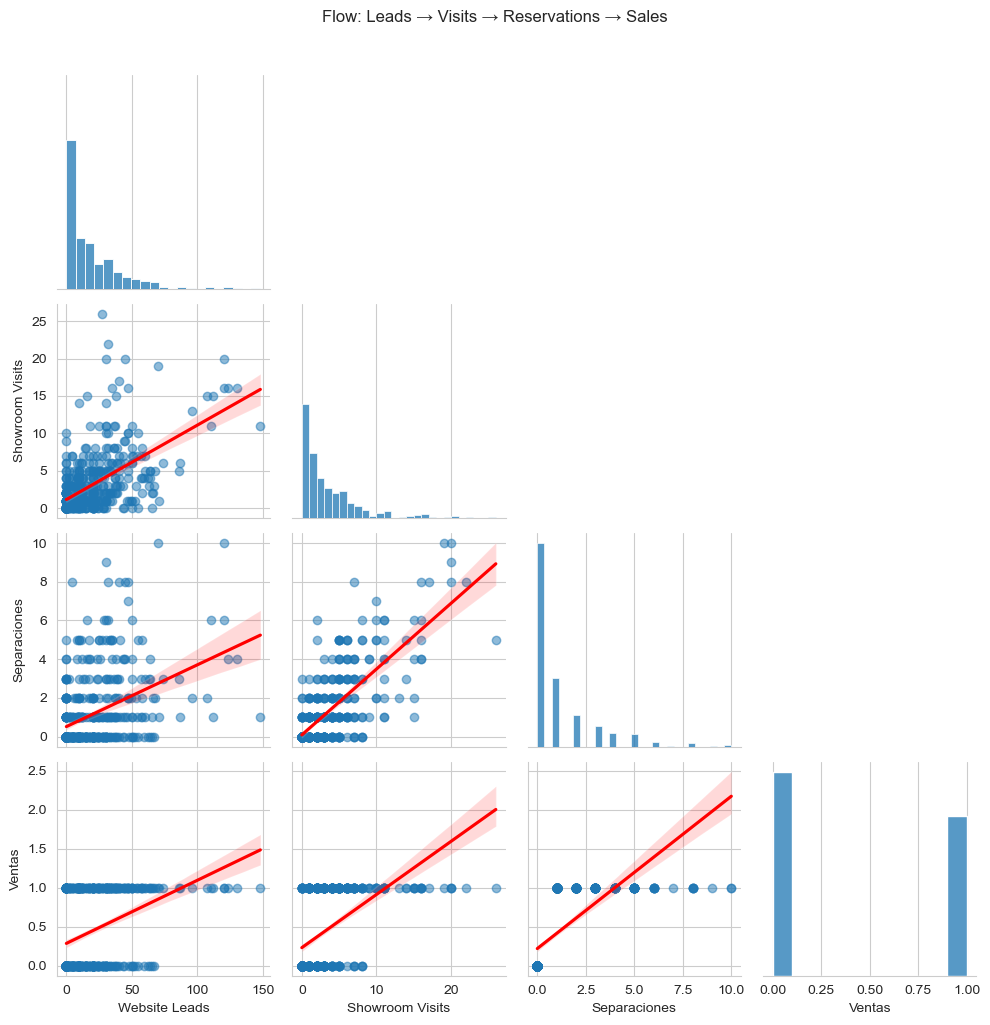

In [148]:
plt.figure(figsize=(10, 6))
sns.pairplot(data, vars=["Website Leads", "Showroom Visits", "Separaciones", "Ventas"], kind="reg", corner=True, plot_kws={'line_kws':{'color':'red'}, 'scatter_kws': {'alpha':0.5}})
plt.suptitle("Flow: Leads → Visits → Reservations → Sales", y=1.02)
plt.tight_layout()
plt.show()

#### Data Preparation - Split data

In [150]:
y = data.pop('Price') # Target column
X = data

In [152]:
# Split the data with 20% to testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

---
## Data Modeling

### Using first Random Forest Regressor

In [154]:
# Params to GridSearchCV
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

In [156]:
# Instantiate model
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid=rf_params, cv=3, n_jobs=-1, scoring='neg_root_mean_squared_error')
rf_grid.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='neg_root_mean_squared_error')

In [158]:
# Get the best estimator
rf_best = rf_grid.best_estimator_
# Predict target
rf_preds = rf_best.predict(X_test)

In [160]:
# Show the best params
rf_grid.best_params_

{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}

### Using XGBoost

In [165]:
# Params to GridSearchCV
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.05, 0.1]
}

In [167]:
# Instantiate model
xgb_grid = GridSearchCV(XGBRegressor(random_state=42, objective="reg:squarederror"), xgb_params, cv=3, n_jobs=-1, scoring='neg_root_mean_squared_error')
xgb_grid.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [3, 6, 10],
                         'n_estimators': [100, 200]},
             scoring='neg_root_mean_squared_error')

In [169]:
# Get the best estimator
xgb_best = xgb_grid.best_estimator_
# Predict target
xgb_preds = xgb_best.predict(X_test)

In [173]:
# Show the best params
xgb_grid.best_params_

{'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 100}

### Using MLP Regressor

In [180]:
# Create a pipeline
nn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(max_iter=1000, random_state=42))
])

In [182]:
# Params to grid
nn_params = {
    'mlp__hidden_layer_sizes': [(64, 32), (100, 50)],
    'mlp__activation': ['relu'],
    'mlp__alpha': [0.0001, 0.001]
}

In [185]:
# Instantiate model
nn_grid = GridSearchCV(nn_pipeline, nn_params, cv=3, n_jobs=-1, scoring='neg_root_mean_squared_error')
nn_grid.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('mlp',
                                        MLPRegressor(max_iter=1000,
                                                     random_state=42))]),
             n_jobs=-1,
             param_grid={'mlp__activation': ['relu'],
                         'mlp__alpha': [0.0001, 0.001],
                         'mlp__hidden_layer_sizes': [(64, 32), (100, 50)]},
             scoring='neg_root_mean_squared_error')

In [187]:
# Get the best estimator
nn_best = nn_grid.best_estimator_
# Predict target
nn_preds = nn_best.predict(X_test)

In [189]:
# Show the best params
nn_grid.best_params_

{'mlp__activation': 'relu',
 'mlp__alpha': 0.001,
 'mlp__hidden_layer_sizes': (100, 50)}

---
## Evaluation

### Create function to get results:

In [193]:
def evaluate_models(results):
    metrics = []

    for name, y_true, y_pred in results:
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        metrics.append({
            "Model": name,
            "RMSE": round(rmse, 2),
            "MAE": round(mae, 2),
            "R² Score": round(r2, 4)
        })

    return pd.DataFrame(metrics).set_index("Model")

In [195]:
results = [
    ("Random Forest", y_test, rf_preds),
    ("XGBoost", y_test, xgb_preds),
    ("Neural Network", y_test, nn_preds)
]

In [197]:
df_metrics = evaluate_models(results)
display(df_metrics)

,RMSE,MAE,R² Score
Model,,,
Random Forest,168393.56,41611.53,0.9796
XGBoost,185439.77,52878.91,0.9753
Neural Network,1096489.88,663742.61,0.1355


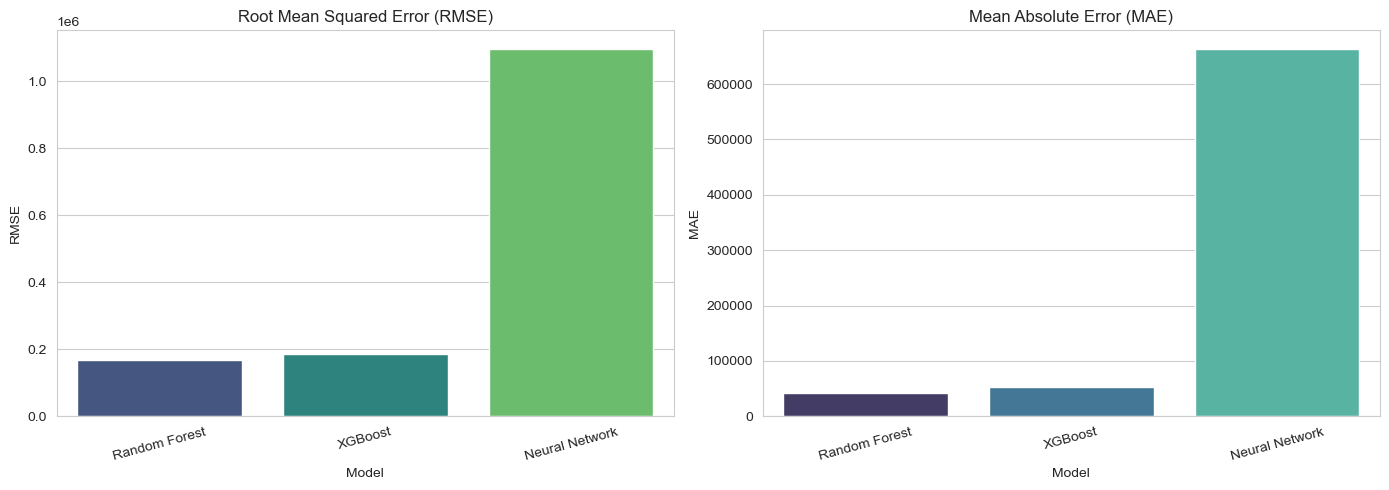

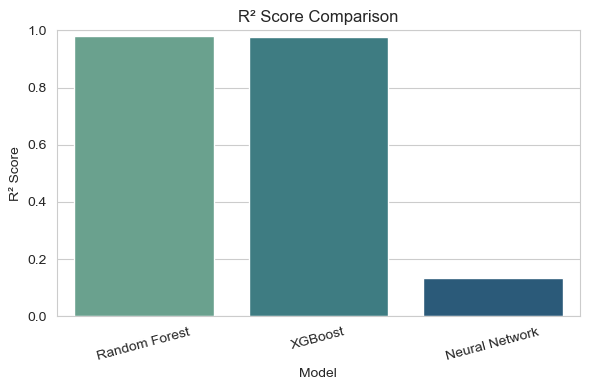

In [199]:
# Gráfica de barras para RMSE y MAE
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df_metrics.reset_index(), x='Model', y='RMSE', ax=axs[0], palette="viridis")
axs[0].set_title('Root Mean Squared Error (RMSE)')
axs[0].set_ylabel("RMSE")
axs[0].tick_params(axis='x', rotation=15)

sns.barplot(data=df_metrics.reset_index(), x='Model', y='MAE', ax=axs[1], palette="mako")
axs[1].set_title('Mean Absolute Error (MAE)')
axs[1].set_ylabel("MAE")
axs[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# Gráfico separado para R² Score
plt.figure(figsize=(6, 4))
sns.barplot(data=df_metrics.reset_index(), x='Model', y='R² Score', palette="crest")
plt.title("R² Score Comparison")
plt.ylabel("R² Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

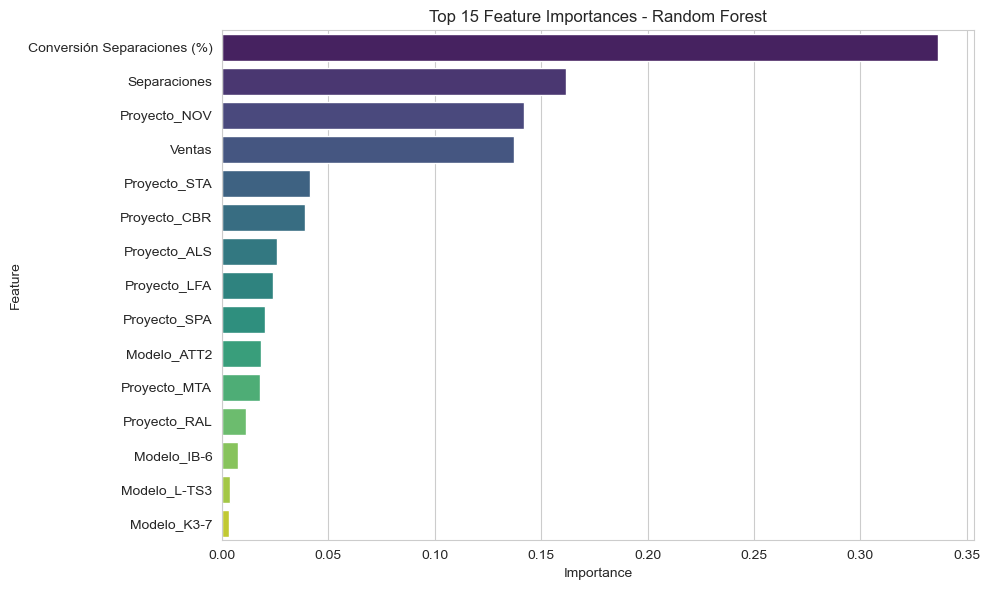

In [205]:
# Get the feature importance
importances = rf_grid.best_estimator_.feature_importances_  # si estás usando GridSearchCV
features = X_train.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Visualización
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importances - Random Forest')
plt.tight_layout()
plt.show()

In this plot, you can see the impact that each feature has on the model's predictions. In this example, 'Conversión Separaciones (%)' and 'Separaciones' are the most important features, meaning they have the greatest influence on the model’s output. Understanding these variables allows you to identify key drivers in the data and optimize decision-making processes.

### Check the partial dependance

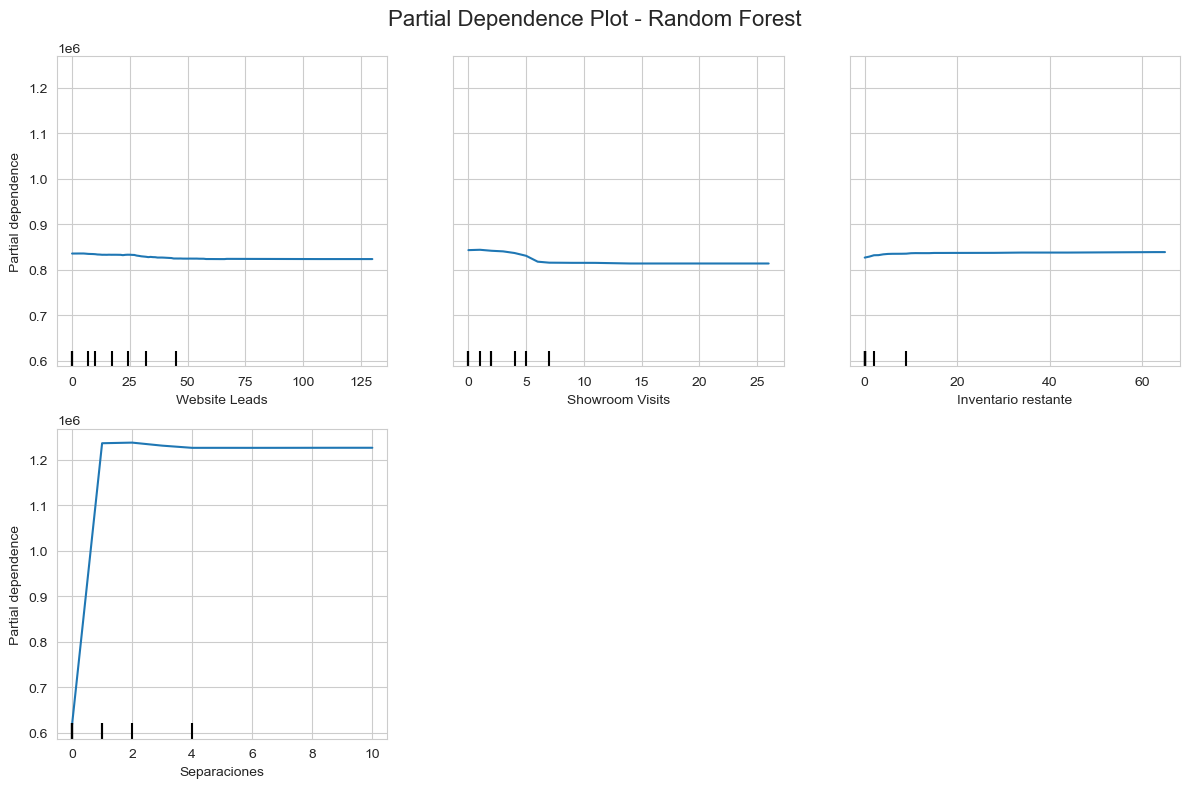

In [214]:
best_rf_model = rf_grid.best_estimator_

# Selecciona las features que quieras analizar
features_to_plot = ['Website Leads', 'Showroom Visits', 'Inventario restante', 'Separaciones']

# Generar el gráfico
fig, ax = plt.subplots(figsize=(12, 8))
PartialDependenceDisplay.from_estimator(
    best_rf_model,
    X_train,
    features=features_to_plot,
    kind="average",  # o "individual" si quieres ver curvas por ejemplo individual
    ax=ax
)
plt.suptitle("Partial Dependence Plot - Random Forest", fontsize=16)
plt.tight_layout()
plt.show()

In this plot, you can visualize how a specific feature affects the model's prediction while keeping all other variables constant. In this example, the feature 'Separaciones' significantly impacts the prediction, as it is one of the most important predictors. This type of analysis also enables 'What if?' scenarios, allowing you to explore how changes in this variable would influence the model’s output.

## Outcomes 

### Model Evaluation – Random Forest

- **R² Score = 0.9796**  
  Indicates an excellent fit: the model explains **97.96%** of the variance in housing prices.

- **RMSE = 168,393.56**  
  Represents a moderate average error in absolute terms, acceptable considering the typical price range.

- **MAE = 41,611.53**  
  Reflects a relatively low average deviation from the actual values, reinforcing the model's robustness.

### Feature Importance Analysis

El modelo identificó las siguientes variables como las más influyentes para predecir el precio de las viviendas:

- **Conversión Separaciones (%)** es, por mucho, la variable más importante. Esto sugiere que la eficiencia en la conversión de leads en separaciones tiene una relación directa y fuerte con el valor final de una propiedad.
  
- **Separaciones** y **Ventas** siguen en importancia, lo que refuerza la idea de que el interés y la acción del cliente están fuertemente vinculados con los precios.

- **Proyecto_NOV**, **Proyecto_STA**, y otros proyectos también aparecen como relevantes, lo que indica que la ubicación o el proyecto específico impacta significativamente en la valuación.

- **Modelo_ATT2** y otras variables de tipo modelo tienen menos influencia directa, pero su presencia sugiere un cierto grado de diferenciación por tipología de unidad.

📌 **Conclusión**: Las variables comerciales (como tasas de conversión y comportamiento de compra) parecen ser más predictivas que las características físicas del inmueble en este dataset. Esto puede guiar decisiones en pricing dinámico, diseño de campañas o análisis de rentabilidad por proyecto.


--- 
## Deployment

In this phase, the objective is to operationalize the results of the data modeling phase. Based on the model's strong performance (R² = 0.9796), the deployment plan could include:

- **Model Integration**: Deploy the Random Forest model in a production environment to provide real-time or scheduled predictions (e.g., pricing recommendations).
- **Dashboarding**: Create dashboards to visualize key insights such as feature importance, predicted values, and business KPIs.
- **Actionable Insights**: Use top features like 'Separaciones' and 'Conversión Separaciones (%)' to guide sales strategies, lead qualification, and inventory planning.
- **What-if Analysis Tools**: Enable users to simulate scenarios by adjusting key inputs (e.g., leads, prices) to understand potential impacts.
- **Retraining Strategy**: Schedule periodic model retraining as new data is collected to maintain performance.